# Machine Learning Methods for Data Streams
## Project: Concept Drift Detection in Polarized News Streams

In [14]:
import requests
import trafilatura
import json
import time
from datetime import datetime
from dateutil.relativedelta import relativedelta
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### 1. Web scraping

This first version of web scraper works with GDELT database, which provides a comprehensive collection of news articles from around the world. 

The scraper retrieves article URLs based on specified keywords and date ranges, then scrapes the full text of each article for further analysis.

In [8]:
SOURCES = {
    "motherjones.com": 0,  #left leaning
    "breitbart.com": 1     #right leaning
}

KEYWORDS = "Trump OR Biden OR President"

START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2026, 3, 1)

OUTPUT_FILE = "polarized_news_stream_light.jsonl" 

In [9]:
def get_article_urls_from_gdelt(domain, query, start_date, end_date, max_retries=15):
    """
    Download list of article URLs from GDELT API for a given domain and query within a date range.
    """
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    start_str = start_date.strftime("%Y%m%d%H%M%S")
    end_str = end_date.strftime("%Y%m%d%H%M%S")
    full_query = f'({query}) domain:{domain}'
    
    params = {
        "query": full_query,
        "mode": "artlist",        
        "maxrecords": 60,         
        "sort": "DateDesc",
        "format": "json",
        "startdatetime": start_str,
        "enddatetime": end_str
    }
    
    for attempt in range(max_retries):
        try:
            time.sleep(3) 
            response = requests.get(url, params=params, timeout=30)
            
            if response.status_code == 429:
                wait_time = 5
                print(f"   [API] Error. Trying again. (Attempt {attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                continue
                
            response.raise_for_status()
            data = response.json()
            
            if "articles" in data and len(data["articles"]) > 0:
                return [(article["url"], article["seendate"]) for article in data["articles"]]
            else:
                print(f"   [API] Found 0 articles. Trying again. (Attempt {attempt+1}/{max_retries})...")
                time.sleep(5)
                continue
                
        except requests.exceptions.Timeout:
            print(f"   [API] Timeout. Trying again. (Attempt {attempt+1}/{max_retries})...")
            time.sleep(5)
        except requests.exceptions.ConnectionError:
            print(f"   [API] Connection Error. Trying again. (Attempt {attempt+1}/{max_retries})...")
            time.sleep(5)
            
    print(f"   [API] {max_retries} failed attempts. Returning no articles.")
    return []

In [10]:
def scrape_article_text(url):
    """
    Download and extract the main text content from a news article URL using trafilatura package.
    """

    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        return trafilatura.extract(downloaded, include_comments=False, include_tables=False)
    return None


In [11]:
def save_articles(output_file):
    """
    Main pipeline for saving articles into a JSON file.
    """
    print(f"Begining collection of articles to file {OUTPUT_FILE}")
        
    with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
        for domain, label in SOURCES.items():
            print(f"Domain: {domain}")
                
            current_date = START_DATE
                
            while current_date < END_DATE:
                print(f"{current_date.strftime('%Y-%m')}...")
                    
                urls_with_dates = get_article_urls_from_gdelt(domain, KEYWORDS, current_date, next_date)
                print(f" Found {len(urls_with_dates)} links.")
                    
                for url, date_str in urls_with_dates:
                    text = scrape_article_text(url)
                        
                    if text and len(text) > 500: 
                        clean_date = datetime.strptime(date_str, "%Y%m%dT%H%M%SZ").isoformat()
        
                        record = {
                            "timestamp": clean_date,
                            "domain": domain,
                            "label": label,
                            "text": text,
                            "url": url
                        }
                    f.write(json.dumps(record, ensure_ascii=False) + "\n")
                        
                    time.sleep(1) 
                
                current_date = nexcurrent_date + relativedelta(months=1) #adds one montht_date

In [ ]:
#save_articles(OUTPUT_FILE)

In [12]:
def audit_data_stream(file_path):
    """
    Check the distribution of articles over time and by source, and visualize it with a bar chart.
    """
    data = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))

    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['timestamp'])
    df['year_month'] = df['datetime'].dt.to_period('M')

    summary = df.groupby(['year_month', 'domain']).size().unstack(fill_value=0) 
    
    print(summary)

    summary.plot(kind='bar', figsize=(12, 6), width=0.8, color=['red', 'blue'])
    
    plt.title('Distribution of articles over time', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Number of downloaded articles', fontsize=12)
    plt.legend(title='Źródło', fontsize=10)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

domain      breitbart.com  motherjones.com
year_month                                
2024-01                44               31
2024-02                17               29
2024-03               106               32
2024-04                42               26
2024-05                29               11
2024-06                82               16
2024-07                34               22
2024-08                89               18
2024-09                41                0
2024-10                65               21
2024-11                71               20
2024-12                83               14
2025-01                44               27
2025-02                33               22
2025-03                67               46
2025-04                61               28
2025-05                69               21
2025-06                91               22
2025-07                23               21
2025-08                68               17
2025-09                32               20
2025-10    

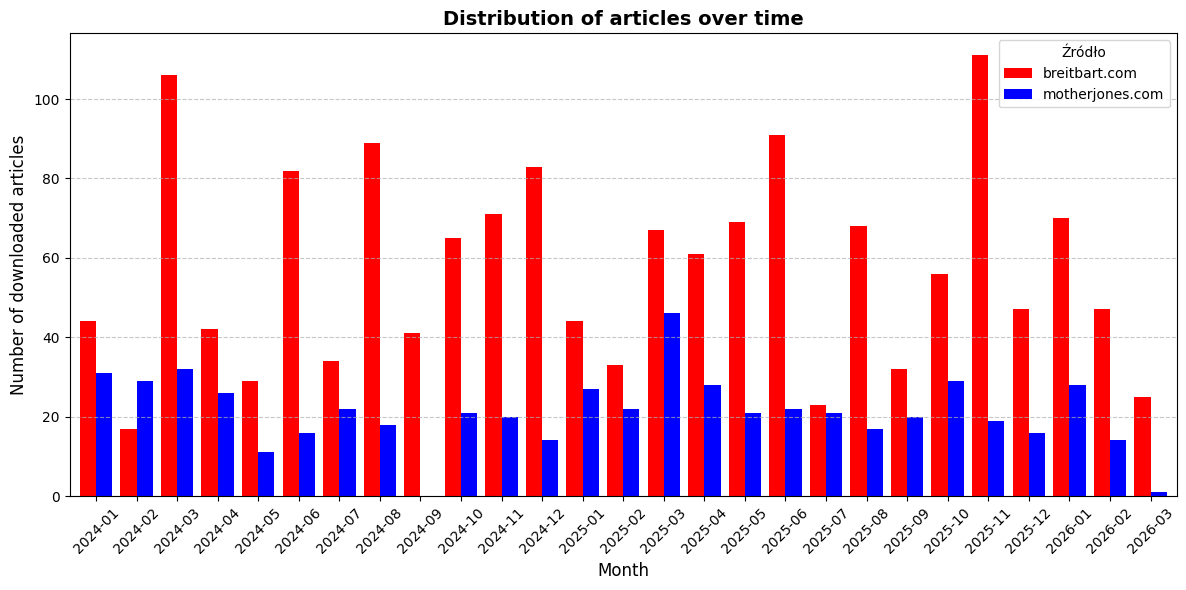

In [ ]:
audit_data_stream(OUTPUT_FILE)